# 1. 환경설정

In [2]:
!pip install koreanize_matplotlib -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import os  # 파일 경로 설정용 모듈
import time
import warnings
warnings.filterwarnings("ignore")

In [4]:
# 데이터 폴더 경로 설정
# base_path = r"/content/drive/MyDrive/코드잇/프로젝트 2/data"
base_path = r"C:\Users\user\Documents\project\data"
file_names = [
    "Application.csv",
    "Company.csv",
    "CompanyAddress.csv",
    "CompanyFund.csv",
    "Job.csv",
    "JobAddress.csv",
    "JobBookmark.csv",
    "log_2022.csv",
    "log_2023.csv"
]

In [5]:
# 파일 불러오기: 파일명을 키로, DataFrame을 값으로 딕셔너리에 저장
dfs = {
    file_name.replace(".csv", "").lower(): pd.read_csv(os.path.join(base_path, file_name), 
                                                       encoding="utf-8", index_col=0)
    for file_name in file_names
}

application = dfs["application"]
company = dfs["company"]
companyaddress = dfs["companyaddress"]
companyfund = dfs["companyfund"]
job = dfs["job"]
jobaddress = dfs["jobaddress"]
jobbookmark = dfs["jobbookmark"]
log_2022 = dfs["log_2022"]
log_2023 = dfs["log_2023"]

# 2. 데이터 전처리

## 1) log_2022

In [6]:
# 원본 보존과 안전한 데이터 가공을 위해 원본 데이터 copy
log_2022_df = log_2022.copy()

In [7]:
# URL 컬럼에서 369,434 건 관측
log_2022_df.isnull().sum()

user_uuid             0
URL              369434
timestamp             0
date                  0
response_code         0
method                0
dtype: int64

In [8]:
# 결측치 제거
log_2022_df.dropna(subset=['URL'], inplace=True)
log_2022_df.reset_index(drop=True, inplace=True)
log_2022_df.isnull().sum()

user_uuid        0
URL              0
timestamp        0
date             0
response_code    0
method           0
dtype: int64

In [9]:
# 완전 동일한 중복값 확인 : 2,286 건
log_2022_df.duplicated().sum()

2286

In [10]:
# 중복값 제거
log_2022_df.drop_duplicates(inplace=True)
log_2022_df.reset_index(drop=True, inplace=True)

In [11]:
log_2022_df.tail(2)

,user_uuid,URL,timestamp,date,response_code,method
9682402,f9387b22-2d7d-4267-8671-2279e2d784b9,@user_id,2022-11-14 12:11:53.841597 UTC,2022-11-14,200,GET
9682403,940b883f-a385-416c-94e2-b5604a78506c,api/companies/id/view,2022-02-03 02:54:20.404898 UTC,2022-02-03,200,POST


In [12]:
# 반응 메서드 확인
log_2022_df['response_code'].unique()

array([200, 400, 302, 404, 500, 409, 401, 405, 503, 403, 301], dtype=int64)

```
[반응 메서드 종류]

- 1xx (조건부 응답)
- 2xx (성공)
- 3xx (리다이렉션, 추가 동작 필요)
- 4xx (요청 오류, 클라이언트 문제)
- 5xx (서버 오류, 서버 문제)

* 200, 302, 301 을 제외하고는 동작하지 않았으니 URL 데이터에서 제외필요
```

In [13]:
# log_22_drop['response_code'].value_counts()
# response_code 가 400번대, 500번대 제거
log_2022_df = log_2022_df[~log_2022_df['response_code'].between(400, 599)]
log_2022_df['response_code'].value_counts()

response_code
200    9504997
302     100209
301          2
Name: count, dtype: int64

In [14]:
# .이하부터 UTC 라는 문자열 제거
log_2022_df['timestamp'] = log_2022_df['timestamp'].str.slice(0, 19)

# UTC 시간을 KST 시간으로 변경
log_2022_df['timestamp'] = pd.to_datetime(log_2022_df['timestamp'], utc=True)
log_2022_df['timestamp'] = log_2022_df['timestamp'].dt.tz_convert('Asia/Seoul').dt.tz_localize(None)

In [15]:
# 2022년 로그에 몇명의 유저가 있는지 확인 : 17,075 개의 유저 확인
log_2022_df['user_uuid'].nunique()

17075

## 2) log_2023

In [16]:
# 원본 보존과 안전한 데이터 가공을 위해 원본 데이터 copy
log_2023_df = log_2023.copy()

In [17]:
# URL 컬럼에서 274,722 건 관측
# log_2023.isnull().sum()

# 결측치 제거
log_2023_df.dropna(subset=['URL'], inplace=True)
log_2023_df.reset_index(drop=True, inplace=True)
log_2023_df.isnull().sum()

user_uuid        0
URL              0
timestamp        0
date             0
response_code    0
method           0
dtype: int64

In [18]:
# 완전 동일한 중복값 확인 : 635 건
log_2023_df.duplicated().sum()

635

In [19]:
# 중복값 제거
log_2023_df.drop_duplicates(inplace=True)
log_2023_df.reset_index(drop=True, inplace=True)

In [20]:
# log_23_drop['response_code'].value_counts()
# response_code 가 400번대, 500번대 제거
log_2023_df = log_2023_df[~log_2023_df['response_code'].between(400, 599)]
log_2023_df['response_code'].value_counts()

response_code
200    6759715
302     102499
301         57
Name: count, dtype: int64

In [21]:
# .이하부터 UTC 라는 문자열 제거
log_2023_df['timestamp'] = log_2023_df['timestamp'].str.slice(0, 19)

# UTC 시간을 KST 시간으로 변경
log_2023_df['timestamp'] = pd.to_datetime(log_2023_df['timestamp'], utc=True)
log_2023_df['timestamp'] = log_2023_df['timestamp'].dt.tz_convert('Asia/Seoul').dt.tz_localize(None)

In [22]:
# 2023년 로그에 몇명의 유저가 있는지 확인 : 15,299 개의 유저 확인
log_2023_df['user_uuid'].nunique()

15299

## 3) 로그 전체데이터 (filter_log_df)

In [23]:
# 2022, 2023 로그 데이터 합치기
log_all_df = pd.concat([log_2022_df, log_2023_df], ignore_index=True)
log_all_df.tail(2)

,user_uuid,URL,timestamp,date,response_code,method
16467477,f5649d90-3016-4747-9924-a05d74ee895e,verify_phone?next_url=/%40kkwangpe,2023-11-14 22:16:11,2023-11-14,200,GET
16467478,f5649d90-3016-4747-9924-a05d74ee895e,@user_id,2023-11-14 22:16:18,2023-11-14,200,GET


In [24]:
# admin 포함된 유저 추출
admin_users = log_all_df[log_all_df['URL'].str.contains('admin', na=False)]['user_uuid'].unique()

# 2. 그 유저 지워
filter_log_df = log_all_df[~log_all_df['user_uuid'].isin(admin_users)]

# 전체 유저 수 (admin 유저 제외)
filter_log_df['user_uuid'].nunique()

21287

## 4) 지원서 테이블(application)

In [25]:
# 원본 보존과 안전한 데이터 가공을 위해 원본 데이터 copy
application_df = application.copy()

In [26]:
application_df.isnull().sum()  # 결측치 0 개

cdate               0
company_uuid        0
job_uuid            0
user_uuid           0
application_uuid    0
dtype: int64

In [27]:
application_df.duplicated().sum()  # 중복값 0 개

0

In [28]:
# .이하부터 제거
application_df['cdate'] = application_df['cdate'].str.slice(0, 19)

# UTC 시간을 KST 시간으로 변경
application_df['cdate'] = pd.to_datetime(application_df['cdate'], utc=True)
application_df['cdate'] = application_df['cdate'].dt.tz_convert('Asia/Seoul')
application_df['cdate'] = application_df['cdate'].dt.tz_localize(None)

In [29]:
# 연도만 추출해서 새로운 컬럼에 저장
application_df['year'] = application_df['cdate'].dt.year
application_all_df = application_df[application_df['year'].isin([2022, 2023])]

In [30]:
# user_uuid 기준으로 정렬 -> 같은 user_uuid 내에서는 cdate 기준으로 정렬
application_all_df  = application_all_df .sort_values(by=['user_uuid', 'cdate'])

In [31]:
# 지원한 유저수 : 10,285명
application_all_df['user_uuid'].nunique()

10287

In [32]:
application_all_df.tail(2)

,cdate,company_uuid,job_uuid,user_uuid,application_uuid,year
64843,2023-12-05 21:18:50,1ece8243-6a14-4c54-b287-531d57892c78,3e8ac012-25d6-4936-b184-0339b06cba53,ffff25ca-c1d7-4fc2-891b-b0df92f95092,4413d144-bbff-417b-ac43-d805a03fbd05,2023
64836,2023-12-05 21:20:55,511d7d98-7af4-4366-b62f-77b408d08e98,d795ffe1-07f2-4e68-a3a4-19dc311724f7,ffff25ca-c1d7-4fc2-891b-b0df92f95092,a73105a0-e514-4a7d-9a0e-6bb6a5e20b0f,2023


## 5) 북마크 테이블(jobbookmark)

In [33]:
# 원본 보존과 안전한 데이터 가공을 위해 원본 데이터 copy
jobbookmark_df = jobbookmark.copy()

In [34]:
jobbookmark_df.isnull().sum()  # 결측치 0 개

cdate        0
job_uuid     0
user_uuid    0
dtype: int64

In [35]:
jobbookmark_df.duplicated().sum()  # 중복값 50 개

50

In [36]:
# 중복값 제거
jobbookmark_df.drop_duplicates(inplace=True)
jobbookmark_df.reset_index(drop=True, inplace=True)

In [37]:
# UTC 시간을 KST 시간으로 변경
jobbookmark_df['cdate'] = pd.to_datetime(jobbookmark_df['cdate'], utc=True)
jobbookmark_df['cdate'] = jobbookmark_df['cdate'].dt.tz_convert('Asia/Seoul')
jobbookmark_df['cdate'] = jobbookmark_df['cdate'].dt.tz_localize(None)

In [38]:
# 연도만 추출해서 새로운 컬럼에 저장
jobbookmark_df['year'] = jobbookmark_df['cdate'].dt.year
jobbookmark_all_df = jobbookmark_df[jobbookmark_df['year'].isin([2022, 2023])]

In [39]:
# user_uuid 기준으로 정렬 -> 같은 user_uuid 내에서는 cdate 기준으로 정렬
jobbookmark_all_df  = jobbookmark_all_df .sort_values(by=['user_uuid', 'cdate']) 

In [40]:
# 북마크 유저수 : 16,625 명
jobbookmark_all_df['user_uuid'].nunique()

16628

## 6) 채용 공고 테이블(job)

In [41]:
# 원본 보존과 안전한 데이터 가공을 위해 원본 데이터 copy
job_df = job.copy()

In [42]:
job_df.isnull().sum()

cdate                     0
mdate                     0
job_field                 0
career_type_string        0
start_date            43531
end_date              22718
allow_remote              0
can_show_salary           0
job_uuid                  0
company_uuid              0
dtype: int64

- start_date는 cdeate와 동일하다는 코멘트가 있음 -> cdate 값으로 채우기
- end_date는 채용마감일로 상시 채용일 경우 비어있을 수 있음 -> '상시채용'으로 채우기

In [43]:
job_df['start_date'] = job_df['start_date'].fillna(job_df['cdate'])
job_df['end_date'] = job_df['end_date'].fillna('상시채용')

In [44]:
# UTC 시간을 KST 시간으로 변경
job_df['cdate'] = pd.to_datetime(job_df['cdate'], utc=True)
job_df['cdate'] = job_df['cdate'].dt.tz_convert('Asia/Seoul')
job_df['cdate'] = job_df['cdate'].dt.tz_localize(None)

In [45]:
# 연도만 추출해서 새로운 컬럼에 저장
job_df['year'] = job_df['cdate'].dt.year
job_all_df = job_df[job_df['year'].isin([2022, 2023])]

## 7) 회사 테이블(company)

In [46]:
# 원본 보존과 안전한 데이터 가공을 위해 원본 데이터 copy
company_df = company.copy()

In [47]:
company_df.isnull().sum()  # 설립일자 결측치 발견 그러나, 분석에 지장가지 않아 그대로 유지

cdate                  0
mdate                  0
found_date         24175
employee_count         0
view_count             0
follow_count           0
reference_count        0
company_uuid           0
dtype: int64

In [48]:
company_df.duplicated().sum()  # 중복값 0

0

In [49]:
# datetime 으로 변경
company_df['cdate'] = pd.to_datetime(company_df['cdate'])

# 연도만 추출해서 새로운 컬럼에 저장
company_df['year'] = company_df['cdate'].dt.year
company_df['period'] = company_df['cdate'].dt.to_period('M')

# 3. 데이터 살펴보기

## job 테이블

### 기간별 공고 수

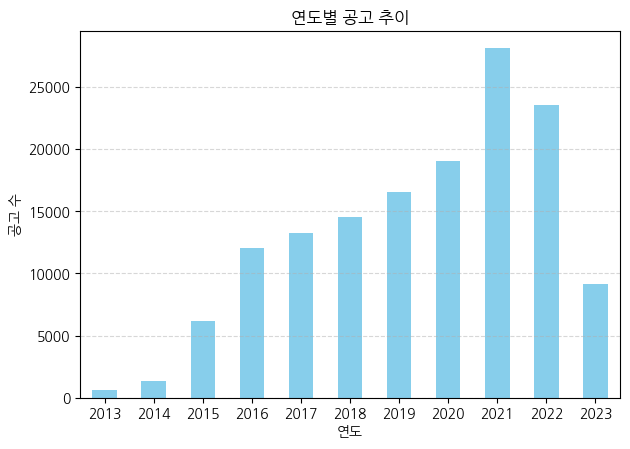

In [ ]:
# 연도별 공고 추이
job_df['year_month'] = job_df['cdate'].dt.year

job_df['year_month'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('연도별 공고 추이')
plt.xlabel('연도')
plt.ylabel('공고 수')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

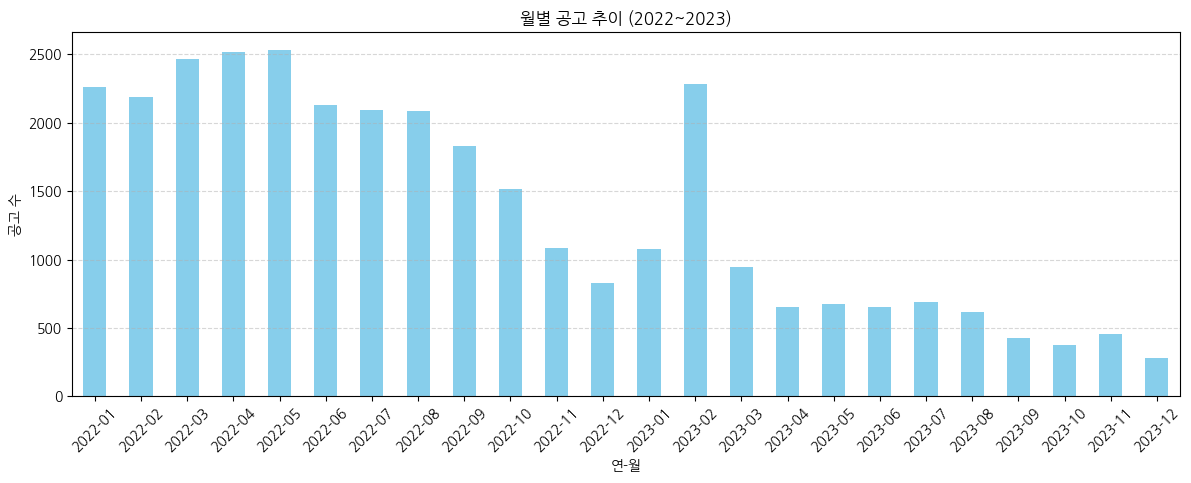

In [ ]:
# 2022년, 2023년 월별 공고 추이
job_df['period'] = job_df['cdate'].dt.to_period('M')
job_df['year'] = job_df['cdate'].dt.year
filtered = job_df[job_df['year'].isin([2022, 2023])]

plt.figure(figsize=(12, 5))
filtered['period'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('월별 공고 추이 (2022~2023)')
plt.xlabel('연-월')
plt.ylabel('공고 수')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

### 공고 업종별 현황

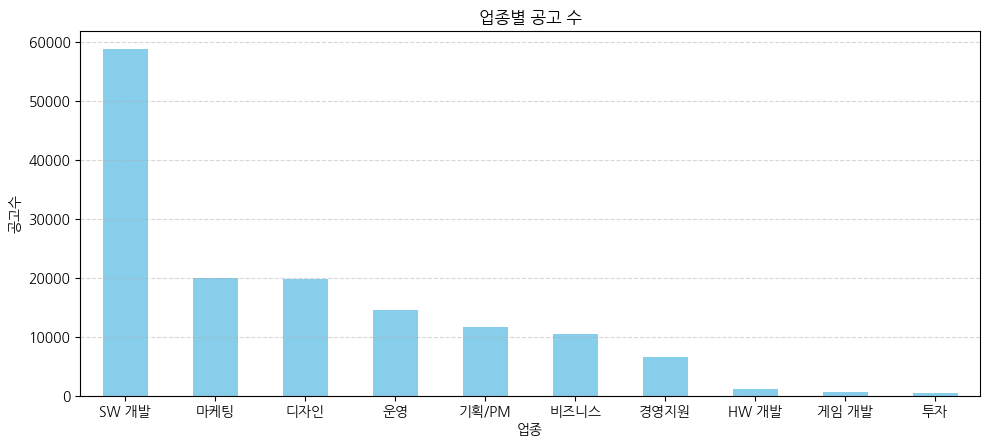

In [195]:
# 공고 업종별 공고 수
plt.figure(figsize=(10, 5))
job_df['job_field'].value_counts().plot(kind='bar', color='skyblue')
plt.title('업종별 공고 수')
plt.xlabel('업종')
plt.ylabel('공고수')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

### 경력 구분

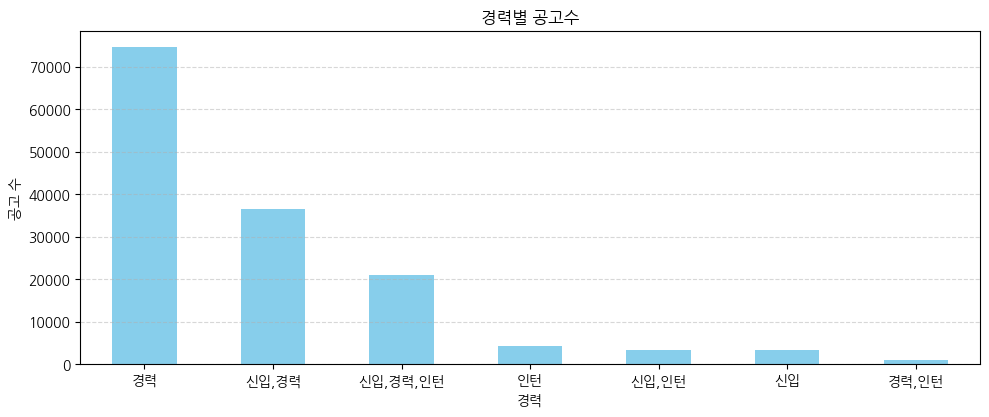

In [196]:
# 경력 구분별 공고 수
plt.figure(figsize=(10, 5))
job_df['career_type_string'].value_counts().plot(kind='bar', color='skyblue')
plt.title('경력별 공고수')
plt.xlabel('경력')
plt.ylabel('공고 수')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

### 업무 분야별 선호하는 경력 형태

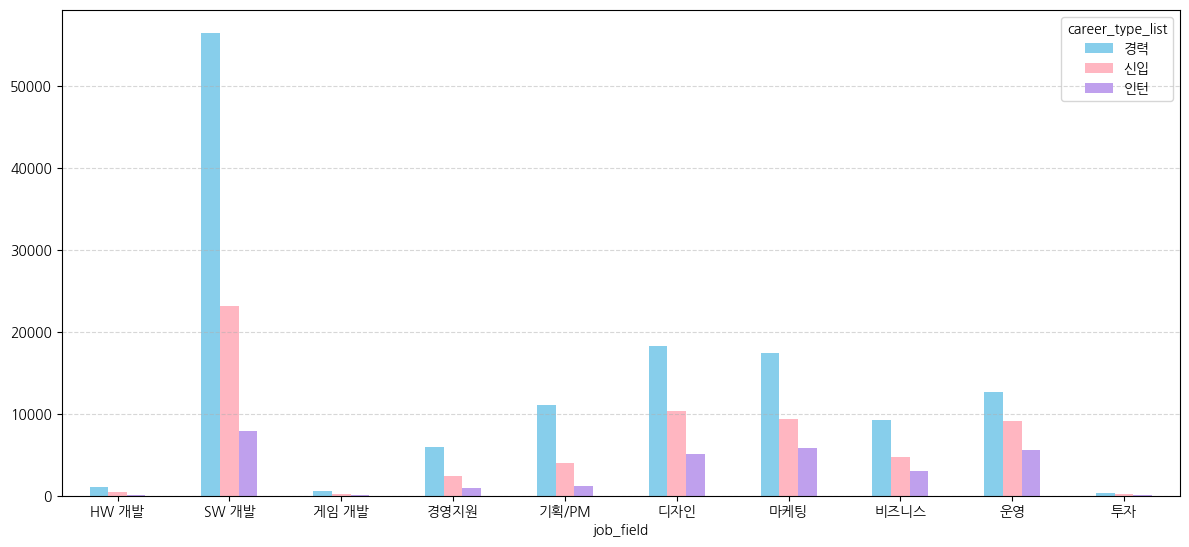

In [197]:
field_type_copy = job_df[['job_field', 'career_type_string']].copy()

# career_type_string 을 , 기준으로 나누기
field_type_copy['career_type_list'] = field_type_copy['career_type_string'].str.split(',')

# explode로 각 경력 유형 하나씩 분리
copy_exploded = field_type_copy.explode('career_type_list')

# 직무별, 경력유형별 공고 수 세기
result = copy_exploded.groupby(['job_field', 'career_type_list']).size().unstack(fill_value=0)
result.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'lightpink', '#BFA0ED'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

## application 테이블

### 기간별 지원 추이

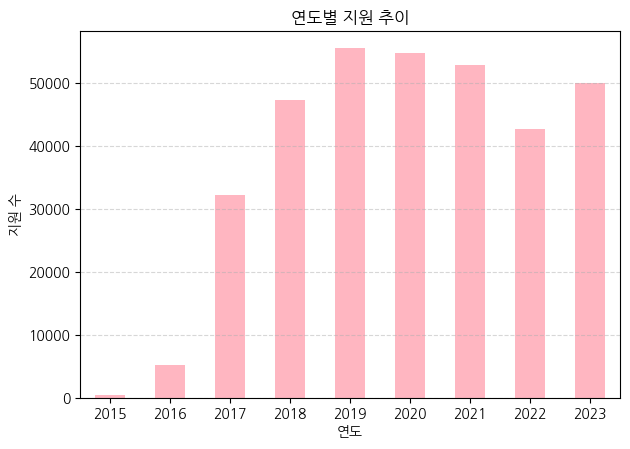

In [ ]:
# 연도별 지원 추이
application_df['year_month'] = application_df['cdate'].dt.year

application_df['year_month'].value_counts().sort_index().plot(kind='bar', color='lightpink')
plt.title('연도별 지원 추이')
plt.xlabel('연도')
plt.ylabel('지원 수')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

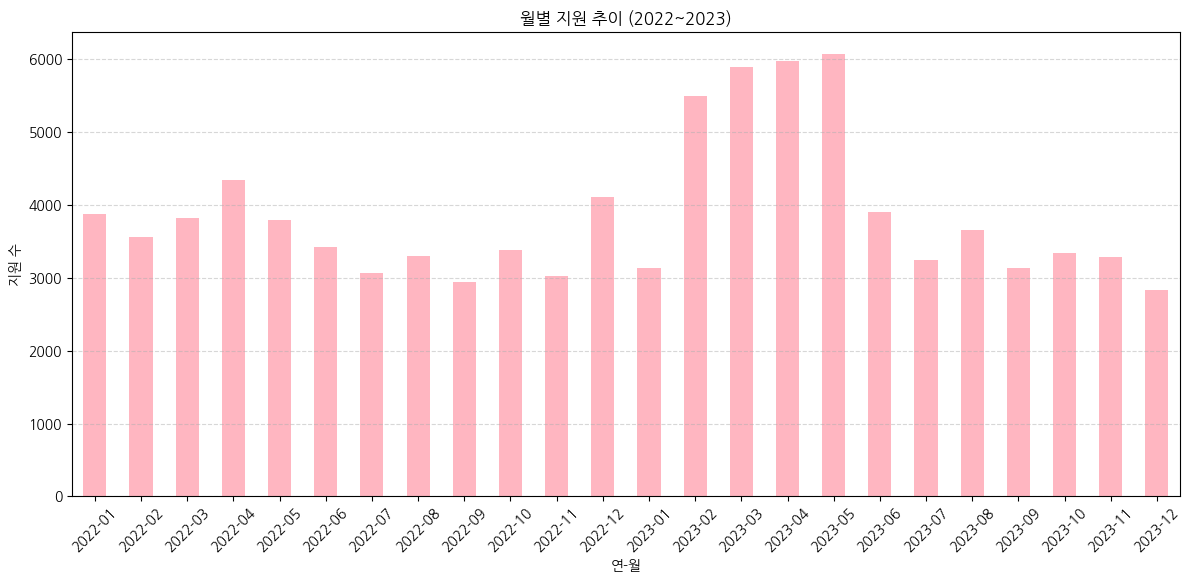

In [194]:
# 2022년, 2023년 월별 지원 추이
application_df['period'] = application_df['cdate'].dt.to_period('M')
application_df['year'] = application_df['cdate'].dt.year
filteredapp = application_df[application_df['year'].isin([2022, 2023])]

plt.figure(figsize=(12,6))
filteredapp['period'].value_counts().sort_index().plot(kind='bar', color='lightpink')
plt.title('월별 지원 추이 (2022~2023)')
plt.xlabel('연-월')
plt.ylabel('지원 수')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# 4. AARRR

- 2022~2023년도에 회원가입을 한 유저는 신규회원으로 2022년도 이전에 가입한 유저를 기존회원으로 간주

## 1) 획득(Acquisition)

### 1. 신규회원 유입

In [50]:
# 회원가입 step1 로그 필터링 : 5984 명
signup = filter_log_df[filter_log_df['URL'].str.contains('signup/step1', case=False, na=False)]

# 해당 유저 리스트 추출
signup_list = signup['user_uuid'].unique()

# 다시 필터링
signup_df = filter_log_df[filter_log_df['user_uuid'].isin(signup_list)]

# 그 중에서 step3/done 로그만 필터링 : 4292 명
signup_step3_df = signup_df[signup_df['URL'].str.contains('signup/step3/done', case=False, na=False)]

In [51]:
# step1까지 한 로그 필터링, 그 중 step3/done까지 완료한 로그 필터링
signup['user_uuid'].nunique(), signup_step3_df['user_uuid'].nunique()

(5984, 4292)

In [52]:
# 신규 유저 아이디별, 타임스탬프의 순서대로 정렬하기
new_acusers_df = signup_step3_df.sort_values(by=['user_uuid', 'timestamp'], ascending=True)  # 기본값 ascending=True 오름차순 

# 신규 유저의 첫 로그 데이터 완성! (전처리시, 유저별, 시간 순으로 정렬처리함)
first_users_df = new_acusers_df.groupby('user_uuid').first().reset_index()

In [53]:
# 신규 유저 아이디만 추출
new_users_id = first_users_df['user_uuid'].unique()

- 22~23년도 회원가입을 하여 채용 지원 혹은 북마크를 한 유저는 4292명으로 확인
- 회원가입만 하고 특정활동은 안한 유저는 제외(회원가입 도중 이탈한 유저를 포함)

#### 첫 로그만 분리

In [58]:
# 시각화를 위해 컬럼 추가
first_users_df['period'] = first_users_df['timestamp'].dt.to_period('M')
first_users_df['year'] = first_users_df['timestamp'].dt.year

In [59]:
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'axes.edgecolor': 'black',    # 축선 색상
    'axes.facecolor': 'none',     # 내부 배경 투명
    'figure.facecolor': 'none',   # 전체 배경 투명
})

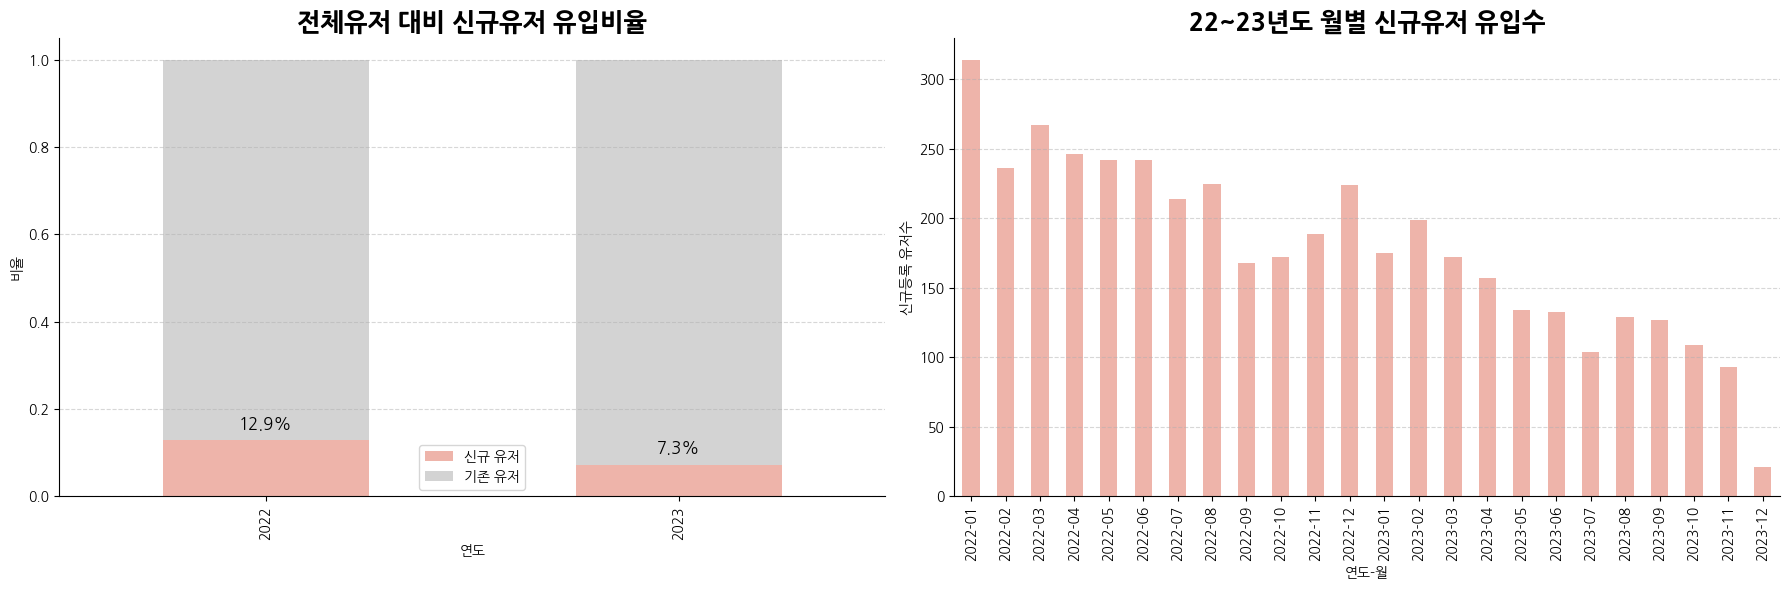

In [201]:
first_users_df_year = first_users_df.groupby('year')['user_uuid'].nunique()
first_users_df_month = first_users_df.groupby('period')['user_uuid'].nunique()

total_users = filter_log_df['user_uuid'].nunique()
signup_ratio = first_users_df_year / total_users
existing_ratio = 1 - signup_ratio
stacked_df = pd.DataFrame({'신규 유저': signup_ratio, '기존 유저': existing_ratio})

# 시각화 (세 그래프 나란히 보기)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 네모 선 없애기 (상단, 우측)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 전체 유저 대비!
stacked_df.plot(kind='bar', stacked=True, ax=axes[0], color=['#EEB4AA', '#D3D3D3'])
axes[0].set_title("전체유저 대비 신규유저 유입비율", fontsize=18, fontweight='bold')
axes[0].set_xlabel('연도')
axes[0].set_ylabel("비율")
axes[0].tick_params(axis='x')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for i, year in enumerate(stacked_df.index):
    new_user_pct = stacked_df.loc[year, '신규 유저']
    axes[0].text(i, new_user_pct + 0.02, f"{new_user_pct:.1%}", 
                 ha='center', va='bottom', fontsize=12, color='black')

# 2022년, 2023년 월별 유저 유입 수
first_users_df_month.plot(kind='bar', ax=axes[1], color='#EEB4AA')
axes[1].set_title('22~23년도 월별 신규유저 유입수', fontsize=18, fontweight='bold')
axes[1].set_xlabel('연도-월')
axes[1].set_ylabel('신규등록 유저수')
axes[1].tick_params(axis='x')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# 레이아웃 조정
plt.tight_layout()
plt.savefig("유입그래프.png", transparent=True)
plt.show()

- 2022년도 이후 신규회원 유입은 점차 줄고 있는 행태
- 취직이나 이직이 되면 채용플랫폼에서 활동성이 떨어지기 때문에 신규회원이 중요함

### 2. 기존회원 재유입

In [54]:
# 전체인원
print(f'전체 인원: {filter_log_df['user_uuid'].nunique()}명')

# 신규인원
print(f'신규 인원: {first_users_df['user_uuid'].nunique()}명')

전체 인원: 21287명
신규 인원: 4292명


In [55]:
# 전체 인원의 로그중 신규회원 로그 제외
old_users_id = filter_log_df[~filter_log_df['user_uuid'].isin(new_users_id)]

In [56]:
# 전체에서 신규회원 로그 제외로그에서 signup 포함된 유저 추출
admin_users2 = old_users_id[old_users_id['URL'].str.contains('signup/step1', na=False)]['user_uuid'].unique()

# 2. 그 유저 제외
current_user = old_users_id[~old_users_id['user_uuid'].isin(admin_users2)]

# 전체 유저 수 (signup 유저 제외)
current_user['user_uuid'].nunique()

15303

In [57]:
# 유저 아이디별, 타임스탬프의 순서대로 정렬하기
current_df = current_user.sort_values(by=['user_uuid', 'timestamp'])  # 기본값 ascending=True 오름차순 

# 기존유저의 첫 로그 데이터 완성 !
current_first_df = current_df.groupby('user_uuid').first().reset_index()

#### 프로필 방문 현황

In [ ]:
# 전체 유저 로그 연-월 컬럼 따로 빼기
filter_log_df['period'] = pd.to_datetime(filter_log_df['timestamp']).dt.to_period('M')

In [62]:
# 프로필 본사람! : 20,039 명
view_user = filter_log_df[filter_log_df['URL'].str.contains('@user_id', case=False, na=False)]
total_view_user_count = view_user['user_uuid'].nunique()

In [63]:
# 파라미터 제외
view_user['clean_url'] = view_user['URL'].str.split(r'\?').str[0]
# view_user['clean_url'].unique()

- '@user_id/applications' 
- '@user_id/job_offer/received' 제거
- '@user_id/following'
- '@user_id/resume'
- '@user_id/bookmark'
- '@user_id/job_offer/sent'
- '@user_id/resume/step1' 제거
- '@user_id/resume/step2' 제거
- '@user_id/activities'
- '@user_id/follower'
- '@user_id/notifications' 제거
- '@user_id/preview'
- '@user_id/likes'
- '@user_id/blockings' 제거

In [64]:
remove_keywords = [
    '/applications',
    '/job_offer/received',
    '/resume/step1',
    '/resume/step2',
    '/notifications',
    '/blockings'
]

# 제거 대상 유저 리스트 추출
remove_users = view_user[view_user['clean_url'].str.contains('|'.join(remove_keywords))]['user_uuid'].unique()

# 제거 대상 제외한 유저 수 세기
filtered_users = view_user[~view_user['user_uuid'].isin(remove_users)]

In [65]:
filter_log_df.head(1)

,user_uuid,URL,timestamp,date,response_code,method,period
0,8a7e70cd-1630-4a8a-8303-0706af3a7908,api/search/language?name=한국어&_=1655915651225,2022-06-23 01:42:48,2022-06-23,200,GET,2022-06


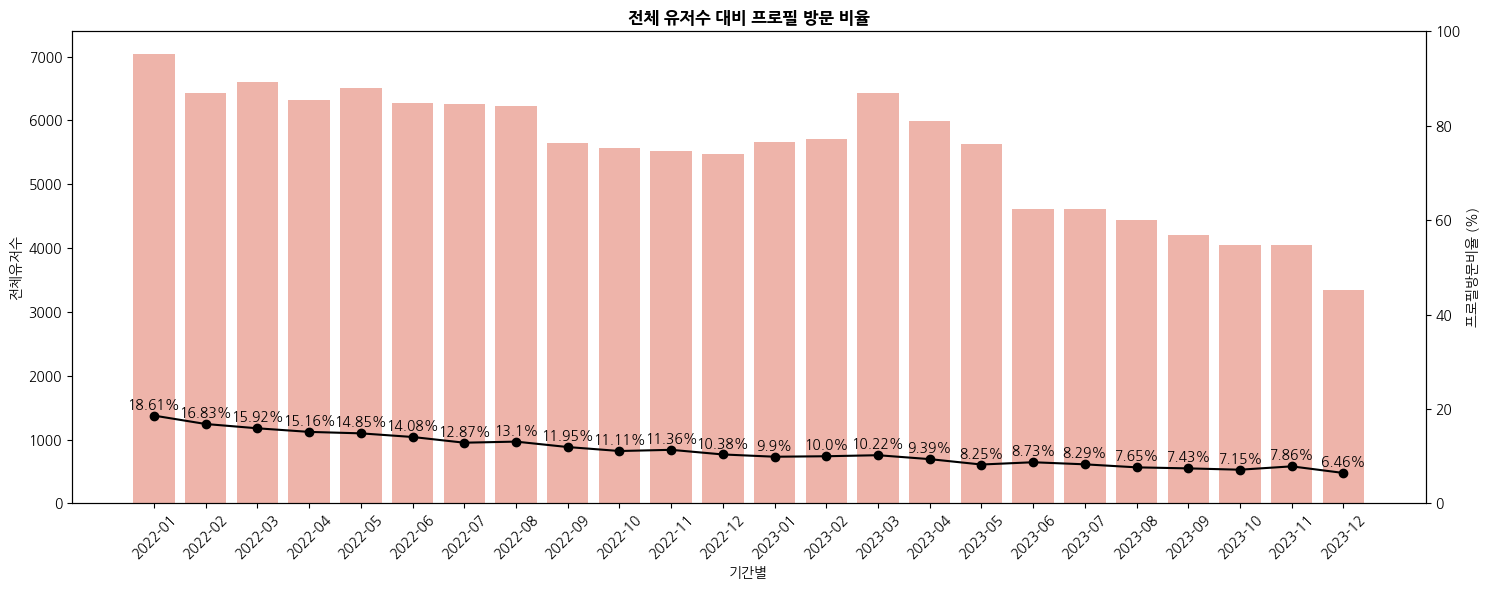

In [206]:
# 월별 전체 유저 수
monthly_total_users = filter_log_df.groupby('period')['user_uuid'].nunique().reset_index(name='total_user_count')

# 월별 실제 프로필 본 유저 수
monthly_real_view_users = filtered_users.groupby('period')['user_uuid'].nunique().reset_index(name='real_view_user_count')

# Merge
monthly_stats = pd.merge(monthly_total_users, monthly_real_view_users, on='period', how='left')
monthly_stats['real_view_user_count'] = monthly_stats['real_view_user_count'].fillna(0)

# 비율 계산
monthly_stats['view_ratio_percent'] = (monthly_stats['real_view_user_count'] / monthly_stats['total_user_count'] * 100).round(2)

# 시각화
fig, ax1 = plt.subplots(figsize=(15, 6))

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 전체 유저
ax1.bar(monthly_stats['period'].astype(str), monthly_stats['total_user_count'], color='#EEB4AA')
ax1.set_ylabel('전체유저수')
ax1.set_xlabel('기간별')
ax1.tick_params(axis='y')
ax1.set_xticklabels(monthly_stats['period'].astype(str), rotation=45)

# 프로필 방문자
ax2 = ax1.twinx()
ax2.plot(monthly_stats['period'].astype(str), monthly_stats['view_ratio_percent'], color='black', marker='o') 
ax2.set_ylabel('프로필방문비율 (%)')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 100)

# 👉 비율 숫자 표시
for i, txt in enumerate(monthly_stats['view_ratio_percent']):
    ax2.annotate(f'{txt}%', 
                 (monthly_stats['period'].astype(str).iloc[i], txt),
                 textcoords="offset points",
                 xytext=(0, 5),  # 위쪽으로 살짝 띄우기
                 ha='center',
                 fontsize=10,
                 color='black')

plt.title('전체 유저수 대비 프로필 방문 비율', fontweight='bold')
fig.tight_layout()
plt.savefig("프로필방문비율.png", transparent=True)
plt.show()

In [76]:
# 사람 페이지에 들어감 : 16,350 명
viewpost_user = filter_log_df[filter_log_df['URL'].str.contains('people', case=False, na=False)]
viewpost_user['user_uuid'].nunique()

16350

## 2) 활성화(Activation)

### 채용지원, 북마크 비율 확인

#### 신규유저 활동 종류 분류

In [77]:
# 신규유저 리스트
new_users_id

array(['000b55ad-5c86-438b-a5b0-9ea3a2917789',
       '0017a738-4fcc-441e-983b-a6033890a9db',
       '00605090-bd12-4978-884b-c74e093b40d0', ...,
       'ffe6aee0-85cc-45e2-aa5e-129751dff08e',
       'ffee959d-51e1-41d1-b662-1e55c7c379bf',
       'fff45252-3c40-4805-99e9-6b650c1fca80'], dtype=object)

In [78]:
# 북마크한 신규유저
bookmark_newusers = jobbookmark_all_df[jobbookmark_all_df['user_uuid'].isin(new_users_id)]['user_uuid'].unique()

# 채용 지원한 신규유저
application_newusers = application_all_df[application_all_df['user_uuid'].isin(new_users_id)]['user_uuid'].unique()

In [79]:
# 집합으로 그룹 지정
bookmark_set = set(bookmark_newusers)
application_set = set(application_newusers)
new_users_set = set(new_users_id)

In [80]:
# 그룹별 계산

# 북마크만한 신규유저
only_bookmark = bookmark_set - application_set

# 채용지원만한 신규유저
only_application = application_set - bookmark_set

# 둘다한 신규유저
both = bookmark_set & application_set

# 북마크 or 지원한 유저 집합
active_users_set = bookmark_set.union(application_set)  # 합집합

# 아무 활동이 없는 유저 = 전체 - 활동한 유저
new_users_no = new_users_set - active_users_set

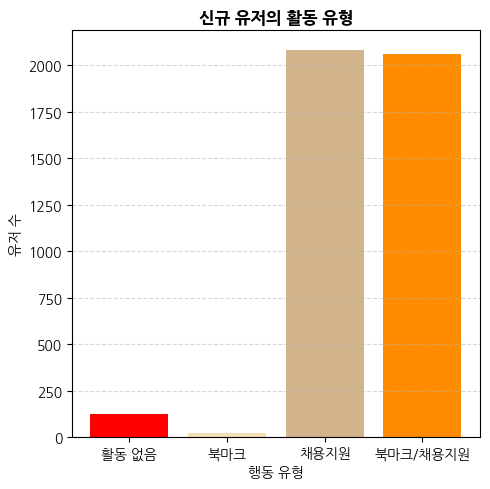

In [200]:
# 신규유저 행동 비율
new_data = {
    '활동 없음' : len(new_users_no),
    '북마크': len(only_bookmark),
    '채용지원': len(only_application),
    '북마크/채용지원': len(both),
}

# 그래프 그리기
plt.figure(figsize=(5, 5))
plt.bar(new_data.keys(), new_data.values(), color=['red', 'wheat', 'tan', 'darkorange'])
plt.title('신규 유저의 활동 유형', fontweight='bold')
plt.ylabel('유저 수')
plt.xlabel('행동 유형')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 기존유저 활동 종류 분류

In [ ]:
# 기존유저 리스트
old_users_id = current_df['user_uuid'].unique()

In [107]:
# 북마크한 기존유저
bookmark_oldusers = jobbookmark_all_df[jobbookmark_all_df['user_uuid'].isin(old_users_id)]['user_uuid'].unique()

# 채용 지원한 기존유저
application_oldusers = application_all_df[application_all_df['user_uuid'].isin(old_users_id)]['user_uuid'].unique()

In [108]:
# 집합으로 그룹 지정
bookmark_set2 = set(bookmark_oldusers)
application_set2 = set(application_oldusers)
old_users_set = set(old_users_id)

In [109]:
# 그룹별 계산

# 북마크만한 기존유저
old_only_bookmark = bookmark_set2 - application_set2

# 채용지원만한 기존유저
old_only_application = application_set2 - bookmark_set2

# 둘다한 기존유저
old_both = bookmark_set2 & application_set2

# 북마크 or 지원한 유저 집합
active_users_set2 = bookmark_set2.union(application_set2)  # 합집합

# 아무 활동이 없는 유저 = 전체 - 활동한 유저
old_users_no = old_users_set - active_users_set2

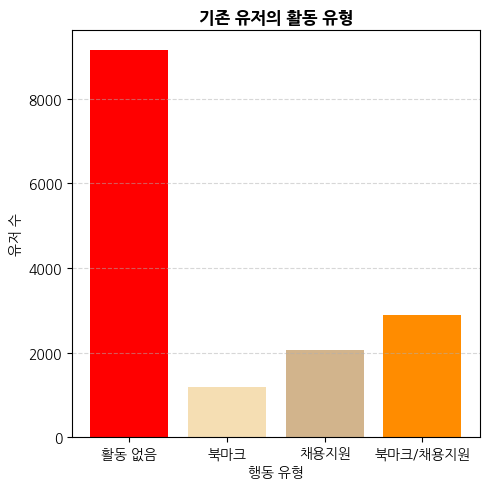

In [199]:
# 기존유저 행동 비율
old_data = {
    '활동 없음' : len(old_users_no),
    '북마크': len(old_only_bookmark),
    '채용지원': len(old_only_application),
    '북마크/채용지원': len(old_both)
}

# 그래프 그리기
plt.figure(figsize=(5, 5))
plt.bar(old_data.keys(), old_data.values(), color=['red', 'wheat', 'tan', 'darkorange'])
plt.title('기존 유저의 활동 유형', fontweight='bold')
plt.ylabel('유저 수')
plt.xlabel('행동 유형')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 기존유저, 신규유저 활동 비율 비교

In [85]:
# 신규 유저 데이터프레임 복사
new_user_act_df = new_acusers_df.copy()
new_user_act_df['category'] = 'neither' 

# apply_all_df와 일치하는 유저에 'apply' 카테고리 추가
new_user_act_df.loc[new_user_act_df['user_uuid'].isin(application_all_df['user_uuid']), 'category'] = 'apply'

# jobbookmark_all_df와 일치하는 유저에 'bookmark' 카테고리 추가
new_user_act_df.loc[new_user_act_df['user_uuid'].isin(jobbookmark_all_df['user_uuid']) & (new_user_act_df['category'] == 'neither'), 'category'] = 'bookmark'

# 'both' 카테고리 추가 (apply와 bookmark 모두 일치하는 경우)
new_user_act_df.loc[new_user_act_df['user_uuid'].isin(application_all_df['user_uuid']) & new_user_act_df['user_uuid'].isin(jobbookmark_all_df['user_uuid']), 'category'] = 'both'

In [86]:
# 기존 유저 데이터프레임 복사
current_user_act_df = current_df.copy()
current_user_act_df['category'] = 'neither'

# apply_all_df와 일치하는 유저에 'apply' 카테고리 추가
current_user_act_df.loc[current_user_act_df['user_uuid'].isin(application_all_df['user_uuid']), 'category'] = 'apply'

# jobbookmark_all_df와 일치하는 유저에 'bookmark' 카테고리 추가
current_user_act_df.loc[current_user_act_df['user_uuid'].isin(jobbookmark_all_df['user_uuid']) & (current_user_act_df['category'] == 'neither'), 'category'] = 'bookmark'

# 'both' 카테고리 추가 (apply와 bookmark 모두 일치하는 경우)
current_user_act_df.loc[current_user_act_df['user_uuid'].isin(application_all_df['user_uuid']) & current_user_act_df['user_uuid'].isin(jobbookmark_all_df['user_uuid']), 'category'] = 'both'

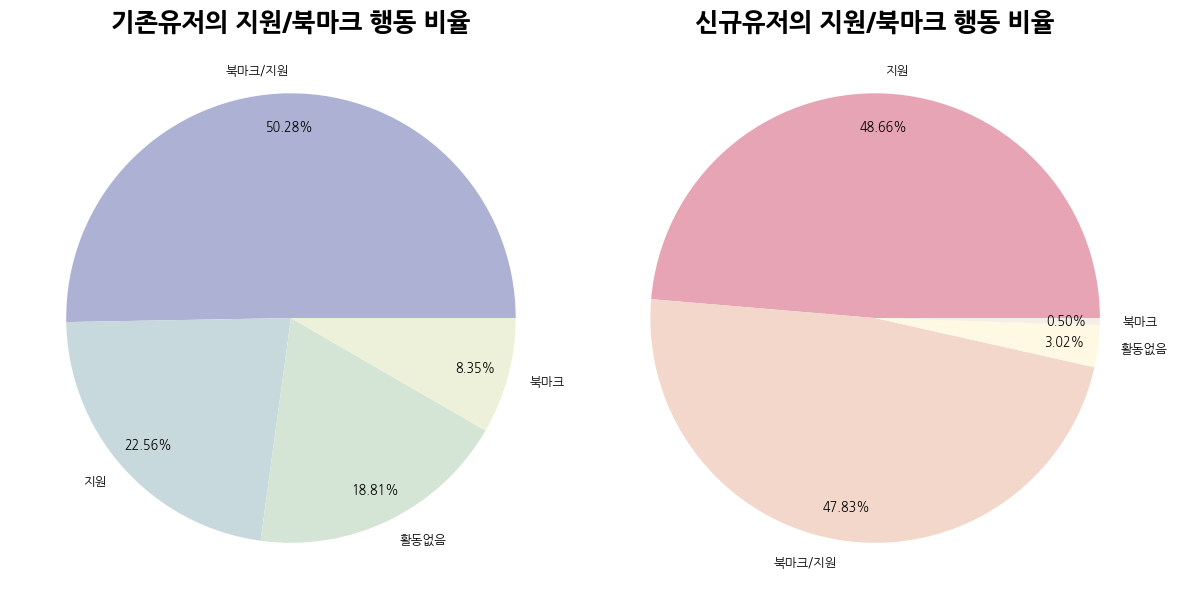

In [215]:
# 비율 계산
new_user_category_counts = new_user_act_df['category'].value_counts(normalize=True) * 100
current_user_category_counts = current_user_act_df['category'].value_counts(normalize=True) * 100

# 시각화 (두 개의 파이 차트를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 원래 인덱스를 한글로 매핑할 딕셔너리
label_map = {
    'neither': '활동없음',
    'bookmark': '북마크',
    'apply': '지원',
    'both': '북마크/지원'
}

# 기존 유저 매핑된 라벨 리스트 만들기
current_custom_labels = [label_map[idx] for idx in current_user_category_counts.index]

# 기존 유저
axes[0].pie(current_user_category_counts,
            labels=current_custom_labels,  # 카테고리 이름 가져오기
            autopct='%1.2f%%',  # 퍼센트 표시 포맷
            colors=['#ADB2D4', '#C7D9DD', '#D5E5D5', '#EEF1DA'],
            textprops={'fontsize': 9, 'color': 'black'},
            pctdistance=0.85)
axes[0].set_title('기존유저의 지원/북마크 행동 비율', fontsize=18, fontweight='bold', color='black')

# 신규 유저 매핑된 라벨 리스트 만들기
new_custom_labels = [label_map[idx] for idx in new_user_category_counts.index]

# 신규 유저
axes[1].pie(new_user_category_counts,
            labels=new_custom_labels,  # 카테고리 이름 가져오기
            autopct='%1.2f%%',  # 퍼센트 표시 포맷
            colors=['#E6A4B4', '#F3D7CA', '#FFF8E3', '#F5EEE6'],
            textprops={'fontsize': 9, 'color': 'black'},
            pctdistance=0.85)
axes[1].set_title('신규유저의 지원/북마크 행동 비율', fontsize=18, fontweight='bold', color='black')

for text in axes[0].texts:
    if '%' in text.get_text():
        text.set_color('black')

for text in axes[1].texts:
    if '%' in text.get_text():
        text.set_color('black')

plt.tight_layout()
plt.savefig("활성비율.png", transparent=True)
plt.show()

- 신규 유저의 지원율이 좀 더 좋음을 알 수 있음

#### 신규 유저 활동유형에 따라 업종 분리

In [ ]:
# 연-월 컬럼 추가
new_user_act_df['period'] = new_user_act_df['timestamp'].dt.to_period('M')

In [112]:
# 신규 유저의 활동 데이터에서 필요한 컬럼만 추출
new_active_check_df = new_user_act_df[['user_uuid', 'period', 'category']]

# 신규 유저 활동 정보에 해당 유저가 지원한 공고(job_uuid) 및 지원 ID(application_uuid)를 병합
new_app_apply_df = new_active_check_df.merge(application_all_df[['user_uuid', 'job_uuid', 'application_uuid']], on='user_uuid', how='left')

In [113]:
# 신규 유저의 지원 이력에 공고 테이블을 병합
new_job_apply_df = new_app_apply_df.merge(job_all_df, on='job_uuid', how='left')

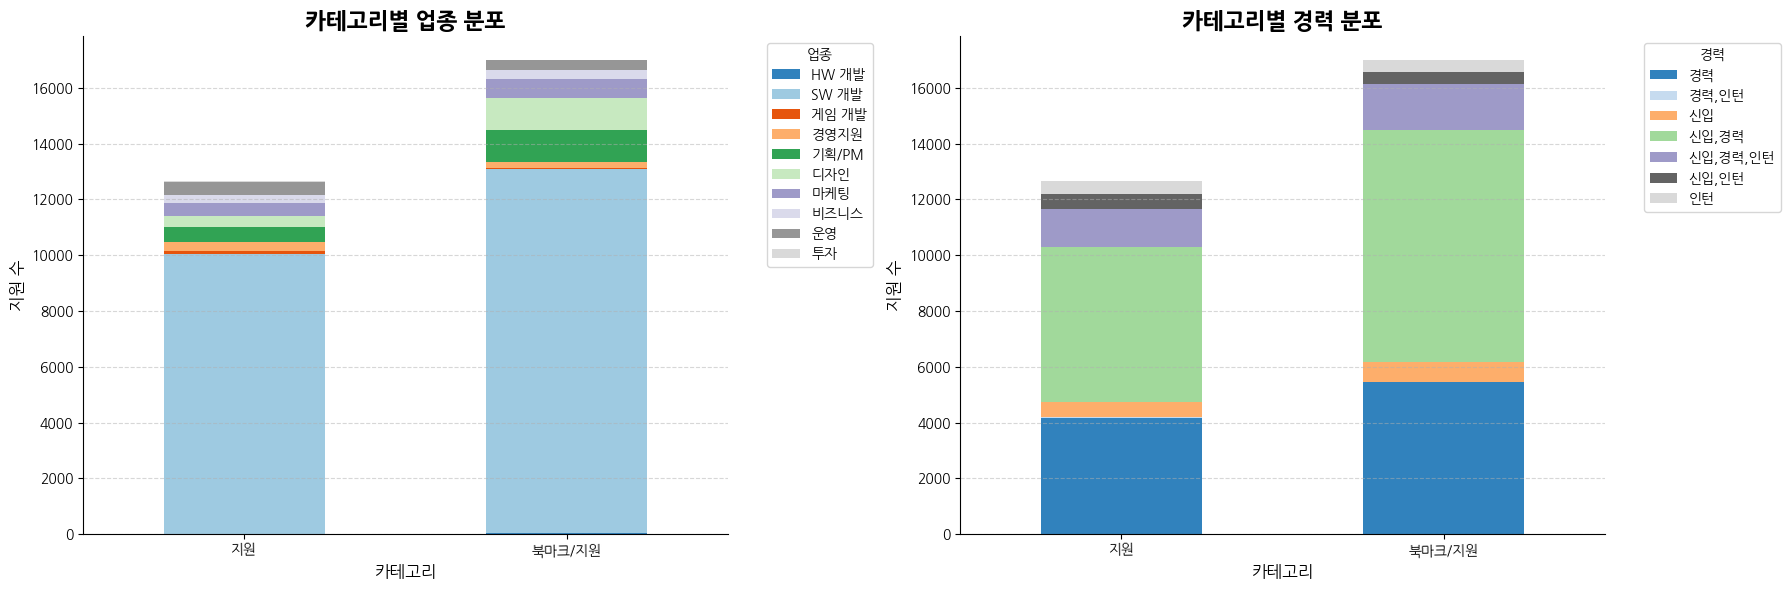

In [208]:
# 업종 분포 계산
job_field_dist = new_job_apply_df.groupby(['category', 'job_field']).size().unstack(fill_value=0)
career_dist = new_job_apply_df.groupby(['category', 'career_type_string']).size().unstack(fill_value=0)

# 시각화 (두 개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 카테고리 한글 라벨로 바꾸기
category_map = {
    'apply' : '지원',
    'both': '북마크/지원'
}

# 인덱스 이름 변경
job_field_dist.rename(index=category_map, inplace=True)
career_dist.rename(index=category_map, inplace=True)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 첫 번째 그래프: 카테고리별 업종 분포
job_field_dist.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20c')
axes[0].set_title('카테고리별 업종 분포', fontsize=16, fontweight='bold')
axes[0].set_xlabel('카테고리', fontsize=12)
axes[0].set_ylabel('지원 수', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=1)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend(title='업종', bbox_to_anchor=(1.05, 1), loc='upper left')

# 두 번째 그래프: 카테고리별 경력 분포
career_dist.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20c')
axes[1].set_title('카테고리별 경력 분포', fontsize=16, fontweight='bold')
axes[1].set_xlabel('카테고리', fontsize=12)
axes[1].set_ylabel('지원 수', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=1)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(title='경력', bbox_to_anchor=(1.05, 1), loc='upper left')

# 레이아웃 조정
plt.tight_layout()
plt.savefig("카테고리별 분포비율.png", transparent=True)
plt.show()

#### 기존 유저 활동유형에 따라 업종 분리

In [120]:
# 채용 지원만한 유저 지원로그
old_only_apply_df = application_all_df[application_all_df['user_uuid'].isin(old_only_application)]

# 북마크만한 유저 지원로그
old_only_bookmark_df = jobbookmark_all_df[jobbookmark_all_df['user_uuid'].isin(old_only_bookmark)]

# 북마크+지원 유저의 지원 로그
old_both_apply_df = application_all_df[application_all_df['user_uuid'].isin(old_both)]

In [121]:
# 지원만 한 사람들
old_only_apply_job = old_only_apply_df.merge(job_all_df, on='job_uuid', how='left')

# 북마크+지원한 사람들
old_both_apply_job = old_both_apply_df.merge(job_all_df, on='job_uuid', how='left')

In [122]:
# 업종별로 묶기
old_only_job_field = old_only_apply_job['job_field'].value_counts(normalize=True)
old_both_job_field = old_both_apply_job['job_field'].value_counts(normalize=True)

# 경력타입별로 묶기기
old_only_career = old_only_apply_job['career_type_string'].value_counts(normalize=True)
old_both_career = old_both_apply_job['career_type_string'].value_counts(normalize=True)

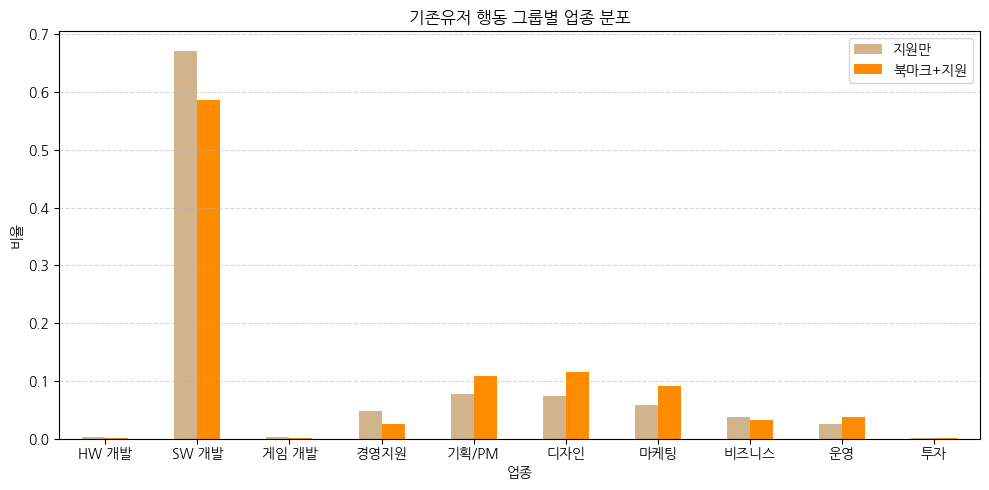

In [209]:
# 업종 기준 비교
old_job_field_df = pd.DataFrame({
    '지원만': old_only_job_field,
    '북마크+지원': old_both_job_field
}).fillna(0)

old_job_field_df.plot(kind='bar', figsize=(10, 5), color=['tan', 'darkorange'])
plt.title('기존유저 행동 그룹별 업종 분포')
plt.xlabel('업종')
plt.ylabel('비율')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

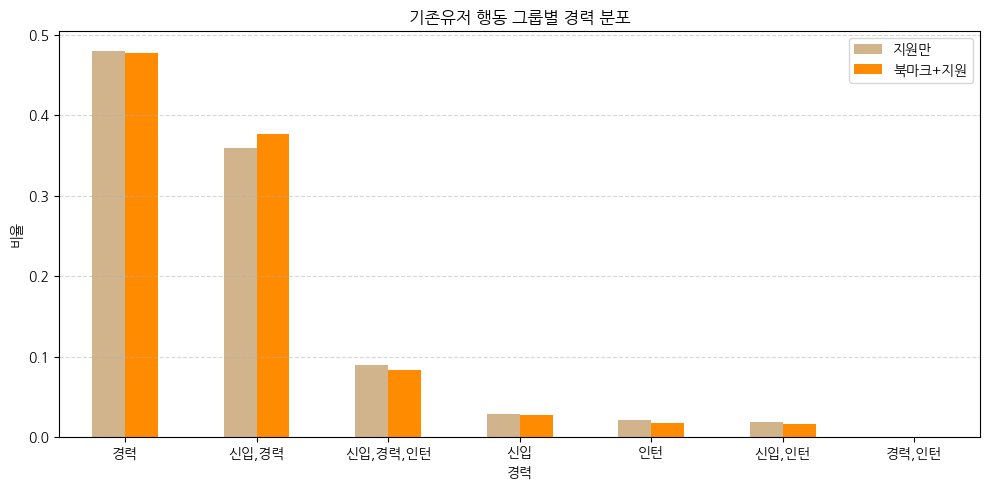

In [210]:
# 경력 기준 비교
old_carrer_df = pd.DataFrame({
    '지원만': old_only_career,
    '북마크+지원': old_both_career
}).fillna(0)

old_carrer_df.plot(kind='bar', figsize=(10, 5), color=['tan', 'darkorange'])
plt.title('기존유저 행동 그룹별 경력 분포')
plt.xlabel('경력')
plt.ylabel('비율')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3) 리텐션(retention)

### 신규회원

In [131]:
# 신규회원의 user_uuid만 필터링
new_users_applications = application_all_df[application_all_df['user_uuid'].isin(first_users_df['user_uuid'])]

In [132]:
new_users_applications.tail(2)

,cdate,company_uuid,job_uuid,user_uuid,application_uuid,year
338390,2023-01-05 22:36:30,211bff9e-8cff-4dbe-b859-a75ea7b9ba88,a4f37260-eb3c-4a83-904c-b4dca0b5e1cb,ffee959d-51e1-41d1-b662-1e55c7c379bf,f075587d-7aef-462e-adf0-72140b171b8d,2023
315202,2023-01-20 18:25:53,d2efba67-b21b-4e03-b8bd-a08a0038126d,ad430078-de45-4b1b-966d-fd06260d2016,fff45252-3c40-4805-99e9-6b650c1fca80,03e0d343-19e4-43cc-a2f9-e1516acb3465,2023


In [133]:
# 유저별 첫 지원일
first_apply_dates = new_users_applications.groupby('user_uuid')['cdate'].min().reset_index()
first_apply_dates.columns = ['user_uuid', 'first_apply_date']

In [134]:
first_apply_dates.tail(2)

,user_uuid,first_apply_date
4143,ffee959d-51e1-41d1-b662-1e55c7c379bf,2023-01-05 22:36:30
4144,fff45252-3c40-4805-99e9-6b650c1fca80,2023-01-20 18:25:53


In [135]:
# 전체지원 + 지원 기록 첫지원일
new_app_with_first = new_users_applications.merge(first_apply_dates, on='user_uuid', how='left')

In [136]:
new_app_with_first.tail()

,cdate,company_uuid,job_uuid,user_uuid,application_uuid,year,first_apply_date
30174,2023-08-21 23:49:28,02d0174f-f16e-48e4-9a9d-6ca8b3d4bde2,695ff81e-47f4-4d66-b1ff-289c46de3153,ffe6aee0-85cc-45e2-aa5e-129751dff08e,a37866ec-f2ad-458a-b3d6-834539a7c9e4,2023,2023-06-08 11:47:31
30175,2023-08-28 09:37:14,efe53c42-55c9-4e53-89e0-4b5de72c9ac5,3719580e-b670-4bbe-8a36-e25821016111,ffe6aee0-85cc-45e2-aa5e-129751dff08e,89d43d25-6ead-483b-bcf0-5d8d7a7aa2b9,2023,2023-06-08 11:47:31
30176,2023-08-29 12:18:25,8e92b00f-525e-428c-9810-2211ab81bb4e,1467f4f1-71d5-4d1d-a0be-66addf4fed16,ffe6aee0-85cc-45e2-aa5e-129751dff08e,8893b9ea-3fd1-4e43-8c13-9d5462386163,2023,2023-06-08 11:47:31
30177,2023-01-05 22:36:30,211bff9e-8cff-4dbe-b859-a75ea7b9ba88,a4f37260-eb3c-4a83-904c-b4dca0b5e1cb,ffee959d-51e1-41d1-b662-1e55c7c379bf,f075587d-7aef-462e-adf0-72140b171b8d,2023,2023-01-05 22:36:30
30178,2023-01-20 18:25:53,d2efba67-b21b-4e03-b8bd-a08a0038126d,ad430078-de45-4b1b-966d-fd06260d2016,fff45252-3c40-4805-99e9-6b650c1fca80,03e0d343-19e4-43cc-a2f9-e1516acb3465,2023,2023-01-20 18:25:53


In [137]:
# 유저별 첫 지원일 기준으로 며칠 후 계산
new_app_with_first['days_after_first'] = (new_app_with_first['cdate'] - new_app_with_first['first_apply_date']).dt.days

In [138]:
new_app_with_first['days_after_first'].describe()

count    30179.000000
mean        58.551542
std        105.932025
min          0.000000
25%          0.000000
50%         14.000000
75%         60.000000
max        706.000000
Name: days_after_first, dtype: float64

- 같은 날 지원한 사람들은 25% 정도로 확인

In [139]:
# 첫 지원을 한 유저 수 (Day 0 기준)
total_users = new_app_with_first['user_uuid'].nunique()

In [140]:
# 첫 지원 이후 재지원만 추출 (Day > 0)
# 같은날 지원은 이탈을 하지 않은 것으로 판단
reapply = new_app_with_first[new_app_with_first['days_after_first'] > 0]

# 리텐션 기준일 설정
retention_days = [1, 5, 10, 15, 30, 60, 90, 120, 150, 180, 210, 270, 300]

In [141]:
print('신규회원')
# 리텐션 결과
retention_results = {}

for day in retention_days:
    retained_users = reapply[reapply['days_after_first'] <= day]['user_uuid'].nunique()
    retention_rate = retained_users / total_users
    retention_results[f'Day {day}'] = f"{retention_rate:.2%}"

# 결과 출력
for day, rate in retention_results.items():
    print(f"{day} 누적리텐션율: {rate}")

신규회원
Day 1 누적리텐션율: 5.96%
Day 5 누적리텐션율: 20.12%
Day 10 누적리텐션율: 37.64%
Day 15 누적리텐션율: 40.55%
Day 30 누적리텐션율: 44.95%
Day 60 누적리텐션율: 47.96%
Day 90 누적리텐션율: 49.24%
Day 120 누적리텐션율: 49.94%
Day 150 누적리텐션율: 50.45%
Day 180 누적리텐션율: 50.90%
Day 210 누적리텐션율: 51.12%
Day 270 누적리텐션율: 51.70%
Day 300 누적리텐션율: 51.92%


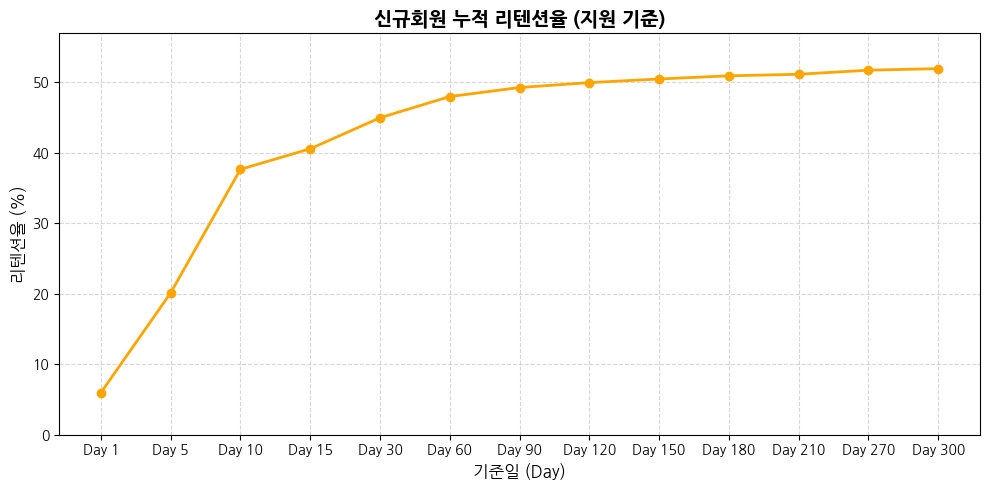

In [211]:
# retention_results를 숫자형으로 변환 (문자 % 제거)
retention_numeric = {k: float(v.strip('%')) for k, v in retention_results.items()}

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(list(retention_numeric.keys()), list(retention_numeric.values()), marker='o', color='orange', linewidth=2)

plt.title('신규회원 누적 리텐션율 (지원 기준)', fontsize=14, fontweight='bold')
plt.xlabel('기준일 (Day)', fontsize=12)
plt.ylabel('리텐션율 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, max(retention_numeric.values()) + 5)  # 보기 좋게 Y축 여유
plt.tight_layout()
plt.show()

### 각 그룹별 리텐션 비교

In [144]:
# 지원한 신규회원 전체
new_users_applications = application_all_df[application_all_df['user_uuid'].isin(first_users_df['user_uuid'])]

# 세그먼트별로 필터링
only_app_df = new_users_applications[new_users_applications['user_uuid'].isin(only_application)]

both_df = new_users_applications[new_users_applications['user_uuid'].isin(both)]

In [145]:
def calculate_retention(df, retention_days=[1, 5, 10, 15, 30, 60, 90, 120, 150, 180, 210, 270, 300]):
    # 첫 지원일
    first_dates = df.groupby('user_uuid')['cdate'].min().reset_index()
    first_dates.columns = ['user_uuid', 'first_apply_date']

    # 병합하여 첫 지원일 기준 차이 계산
    df = df.merge(first_dates, on='user_uuid', how='left')
    df['days_after_first'] = (df['cdate'] - df['first_apply_date']).dt.days

    # 전체 유저 수
    total_users = df['user_uuid'].nunique()

    # 재지원만 필터링 (Day > 0)
    reapply = df[df['days_after_first'] > 0]

    # 리텐션 계산
    retention_results = {}
    for day in retention_days:
        retained = reapply[reapply['days_after_first'] <= day]['user_uuid'].nunique()
        rate = retained / total_users
        retention_results[f'Day {day}'] = round(rate * 100, 2)

    return retention_results

In [146]:
ret_only_app = calculate_retention(only_app_df)
ret_both = calculate_retention(both_df)

In [147]:
print("[지원만 한 신규유저] 리텐션:")
for day, rate in ret_only_app.items():
    print(f"{day}: {rate}%")

print("[북마크+지원 신규유저] 리텐션:")
for day, rate in ret_both.items():
    print(f"{day}: {rate}%")

[지원만 한 신규유저] 리텐션:
Day 1: 4.51%
Day 5: 15.89%
Day 10: 29.52%
Day 15: 32.02%
Day 30: 35.19%
Day 60: 37.3%
Day 90: 38.26%
Day 120: 38.93%
Day 150: 39.27%
Day 180: 39.56%
Day 210: 39.65%
Day 270: 39.94%
Day 300: 40.18%
[북마크+지원 신규유저] 리텐션:
Day 1: 7.42%
Day 5: 24.39%
Day 10: 45.83%
Day 15: 49.18%
Day 30: 54.8%
Day 60: 58.73%
Day 90: 60.33%
Day 120: 61.06%
Day 150: 61.74%
Day 180: 62.37%
Day 210: 62.71%
Day 270: 63.58%
Day 300: 63.77%


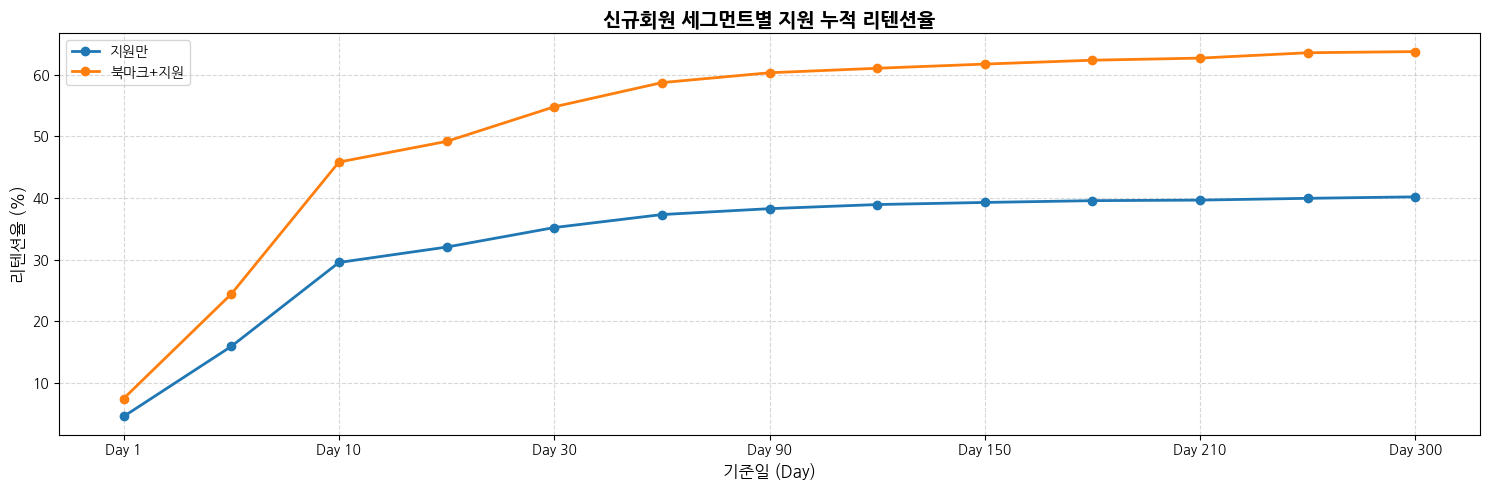

In [213]:
# DataFrame으로 묶기
retention_df = pd.DataFrame({
    '지원만': ret_only_app,
    '북마크+지원': ret_both
})

# 그래프 그리기 (꺾은선 그래프)
retention_df.plot(kind='line', figsize=(15, 5), marker='o', linewidth=2)

plt.title('신규회원 세그먼트별 지원 누적 리텐션율', fontsize=14, fontweight='bold')
plt.ylabel('리텐션율 (%)', fontsize=12)
plt.xlabel('기준일 (Day)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- 리텐션율 확인 했을 때, 신규회원 기준 지원만한 유저보다 북마크와 지원 모두 같이 한 유저들이 리텐션율이 높은 것을 확인
- 지원도 중요하지만 북마크도 함께하는 것이 중요하다고 판단
- 10일 이내 활동 리텐션이 가장 높은 것을 확인 -> 10일 이후 신규 채용공고 알림등의 전략이 있으면 좋을듯 

### 기존회원

In [150]:
# 기존회원의 user_uuid만 필터링
old_users_applications = application_all_df[application_all_df['user_uuid'].isin(current_df['user_uuid'])]

In [151]:
old_users_applications.tail(2)

,cdate,company_uuid,job_uuid,user_uuid,application_uuid,year
64843,2023-12-05 21:18:50,1ece8243-6a14-4c54-b287-531d57892c78,3e8ac012-25d6-4936-b184-0339b06cba53,ffff25ca-c1d7-4fc2-891b-b0df92f95092,4413d144-bbff-417b-ac43-d805a03fbd05,2023
64836,2023-12-05 21:20:55,511d7d98-7af4-4366-b62f-77b408d08e98,d795ffe1-07f2-4e68-a3a4-19dc311724f7,ffff25ca-c1d7-4fc2-891b-b0df92f95092,a73105a0-e514-4a7d-9a0e-6bb6a5e20b0f,2023


In [152]:
# 유저별 첫 지원일
old_first_apply_dates = old_users_applications.groupby('user_uuid')['cdate'].min().reset_index()
old_first_apply_dates.columns = ['user_uuid', 'first_apply_date']

In [153]:
# 전체지원 + 지원 기록 첫지원일
old_app_with_first = old_users_applications.merge(old_first_apply_dates, on='user_uuid', how='left')

In [154]:
# 유저별 첫 지원일 기준으로 며칠 후 계산
old_app_with_first['days_after_first'] = (old_app_with_first['cdate'] - old_app_with_first['first_apply_date']).dt.days

In [155]:
old_app_with_first['days_after_first'].describe()

count    44097.000000
mean       124.700456
std        172.540503
min          0.000000
25%          2.000000
50%         36.000000
75%        192.000000
max        724.000000
Name: days_after_first, dtype: float64

In [156]:
# 첫 지원을 한 유저 수 (Day 0 기준)
old_total_users = old_app_with_first['user_uuid'].nunique()

In [157]:
# 첫 지원 이후 재지원만 추출 (Day > 0)
# 같은날 지원은 이탈을 하지 않은 것으로 판단
old_reapply = old_app_with_first[old_app_with_first['days_after_first'] > 0]

# 리텐션 기준일 설정
retention_days = [1, 5, 10, 15, 30, 60, 90, 120, 150, 180, 210, 270, 300]

In [158]:
# 리텐션 결과
print('기존회원')
old_retention_results = {}

for day in retention_days:
    retained_oldusers = old_reapply[old_reapply['days_after_first'] <= day]['user_uuid'].nunique()
    old_retention_rate = retained_oldusers / old_total_users
    old_retention_results[f'Day {day}'] = f"{old_retention_rate:.2%}"

# 결과 출력
for day, rate in old_retention_results.items():
    print(f"{day} 누적리텐션율: {rate}")

기존회원
Day 1 누적리텐션율: 7.26%
Day 5 누적리텐션율: 21.33%
Day 10 누적리텐션율: 35.58%
Day 15 누적리텐션율: 39.62%
Day 30 누적리텐션율: 45.12%
Day 60 누적리텐션율: 49.02%
Day 90 누적리텐션율: 51.24%
Day 120 누적리텐션율: 52.29%
Day 150 누적리텐션율: 53.43%
Day 180 누적리텐션율: 54.36%
Day 210 누적리텐션율: 54.88%
Day 270 누적리텐션율: 55.63%
Day 300 누적리텐션율: 56.24%


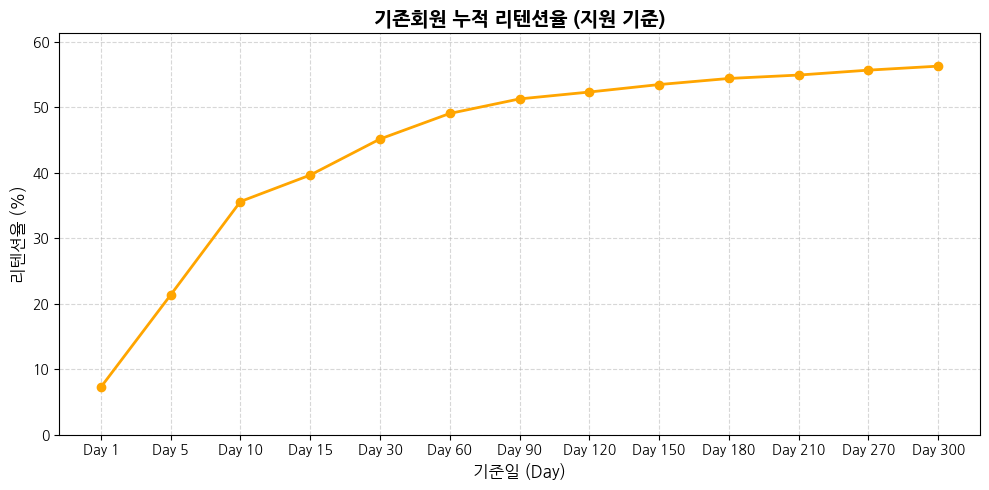

In [214]:
# retention_results를 숫자형으로 변환 (문자 % 제거)
old_retention_numeric = {k: float(v.strip('%')) for k, v in old_retention_results.items()}

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(list(old_retention_numeric.keys()), list(old_retention_numeric.values()), marker='o', color='orange', linewidth=2)

plt.title('기존회원 누적 리텐션율 (지원 기준)', fontsize=14, fontweight='bold')
plt.xlabel('기준일 (Day)', fontsize=12)
plt.ylabel('리텐션율 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, max(old_retention_numeric.values()) + 5)  # 보기 좋게 Y축 여유
plt.tight_layout()
plt.show()

### 월별 코호트, 기간 리텐션

In [160]:
def calculate_monthly_retention(df):
    # (1) cdate를 datetime으로 변환하고 월 시작일로 변환
    df['cdate'] = pd.to_datetime(df['cdate'])
    df['date'] = df['cdate'].dt.to_period('M').apply(lambda r: r.start_time)

    # (2) 유저별 최초 core event(지원서 제출) 날짜를 cohort로 설정
    df['cohort'] = df.groupby('user_uuid')['date'].transform('min')

    # (3) cohort-date 조합으로 유저 수 집계
    df_cohort = df.groupby(['cohort', 'date']).agg(user_count=('user_uuid', 'nunique')).reset_index()

    # (4) 각 row에서 몇 개월 차이인지 계산 (diff)
    df_cohort['diff'] = ((df_cohort['date'] - df_cohort['cohort']).dt.days // 30).astype(int)

    # (5) pivot 테이블 생성 (cohort x month)
    cohort_pivot = df_cohort.pivot_table(index='cohort', columns='diff', values='user_count')

    # (6) cohort별 최초 유저 수 (month 0 기준)
    cohort_sizes = cohort_pivot[0]

    # (7) 비율 계산 (유지율)
    retention = cohort_pivot.divide(cohort_sizes, axis=0)

    return retention, cohort_pivot

In [161]:
def plot_retention_heatmap(retention_rate):
    plt.figure(figsize=(15, 8))
    sns.heatmap(
        retention_rate, 
        annot=True, fmt=".0%", cmap="YlGnBu", 
        linewidths=.5, cbar_kws={'label': 'Retention Rate'}
    )
    plt.title('리텐션 매트릭스', fontsize=18)
    plt.xlabel('월별', fontsize=12)
    plt.ylabel('코호트 (신규유저의 첫 행동 월)', fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [162]:
# 기존회원의 user_uuid만 필터링
old_users_applications = application_all_df[application_all_df['user_uuid'].isin(current_df['user_uuid'])]

In [ ]:
# 기존 유저 기준 리텐션 계산
# c: retention 비율, d: cohort별 유저 수
c, d = calculate_monthly_retention(old_users_applications)

In [164]:
# 신규회원의 user_uuid만 필터링
new_users_applications = application_all_df[application_all_df['user_uuid'].isin(signup_step3_df['user_uuid'])]

In [165]:
# 신규 유저 기준 리텐션 계산
# e: retention 비율, f: cohort별 유저 수
e, f = calculate_monthly_retention(new_users_applications)

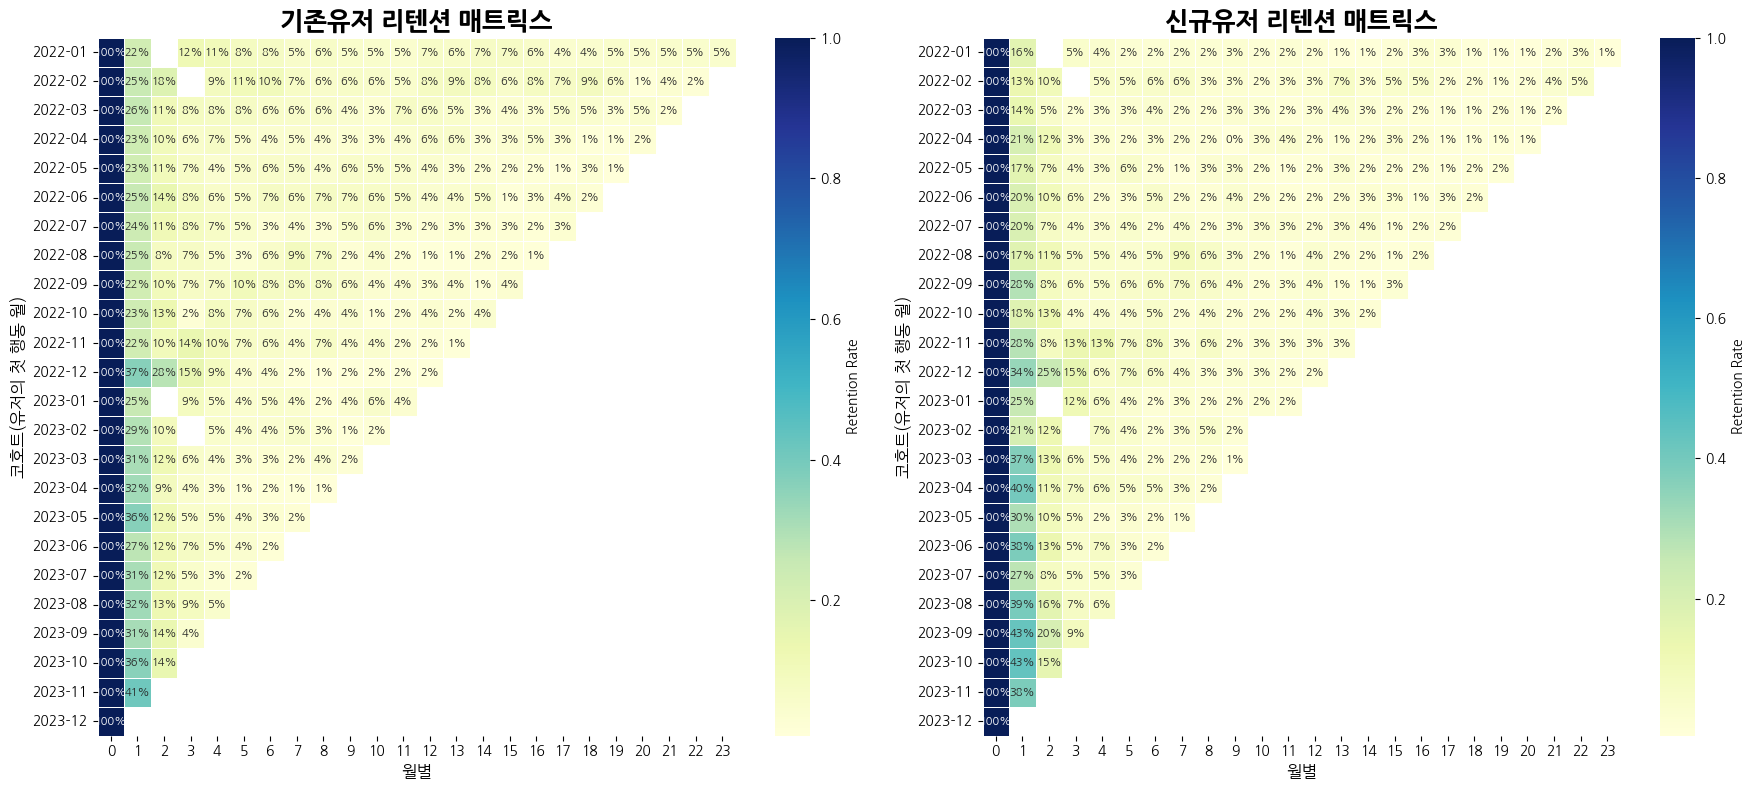

In [166]:
# y축 값을 연도-월 형식으로 변경
y_labels = pd.date_range(start="2022-01-01", periods=c.shape[0], freq='M').strftime('%Y-%m')

# 두 개의 히트맵을 나란히 보기 위한 서브플롯 설정
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # 1행 2열 서브플롯

# 첫 번째 히트맵 
sns.heatmap(
    c, 
    annot=True, fmt=".0%", cmap="YlGnBu", 
    linewidths=.5, cbar_kws={'label': 'Retention Rate'},
    ax=axes[0],
    yticklabels=y_labels,  # y축 레이블 설정
    annot_kws={"size": 8}  # 비율 텍스트 폰트 크기 설정
)
axes[0].set_title('기존유저 리텐션 매트릭스', fontsize=18, fontweight='bold')
axes[0].set_xlabel('월별', fontsize=12)
axes[0].set_ylabel('코호트(유저의 첫 행동 월)', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# 두 번째 히트맵 
sns.heatmap(
    e, 
    annot=True, fmt=".0%", cmap="YlGnBu", 
    linewidths=.5, cbar_kws={'label': 'Retention Rate'},
    ax=axes[1],
    yticklabels=y_labels,  # y축 레이블 설정
    annot_kws={"size": 8}  # 비율 텍스트 폰트 크기 설정
)
axes[1].set_title('신규유저 리텐션 매트릭스', fontsize=18, fontweight='bold')
axes[1].set_xlabel('월별', fontsize=12)
axes[1].set_ylabel('코호트(유저의 첫 행동 월)', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

# 서브플롯 간 간격 조정
plt.tight_layout()
plt.show()

## 4) 수익화(Revenue)

- 매출이나 지원에 대한 수익 관계 테이블 존재 하지 않아 직접적인 확인이 어려움
- 해당 채용플랫폼 유저들이 채용이 많이 될 수록 수익화가 발생된다고 판단
- 여러 채용공고에 지원을 많이 할수록 채용이 많아질 것
- 지원율을 올리는 방안으로 수익화 개선

## 5) 추천(Referral)

- 이후 인사이트 기반 광고나 이벤트로 바이럴 진행 후 데이터셋 필요
- 이벤트 진행여부나 바이럴을 통해 유저들이 유입된 트래킹 경로를 알 수 없어 데이터로 확인이 불가